In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fftpack import fft

#### Setting filter parameters

In [42]:
srate = 1024
nyquist = srate/2
frange = [20,45]
transw = .1
order = int(5*srate/frange[0])

if order%2==0:
    order+=1

#### FIR Kernel

In [43]:
filtker = signal.firwin(order, frange, fs=srate, pass_zero=False)

Plot

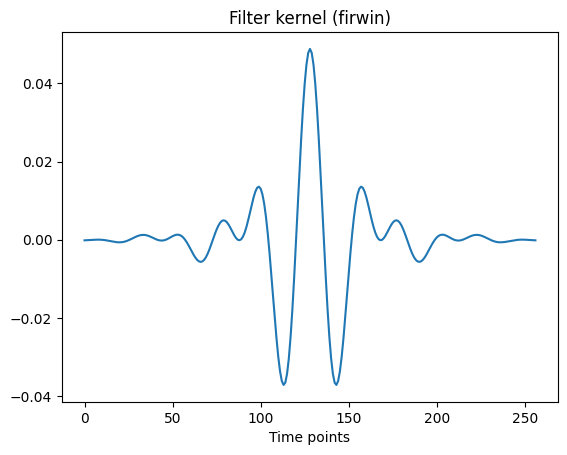

In [44]:
plt.plot(filtker)
plt.xlabel("Time points")
plt.title("Filter kernel (firwin)")
plt.show()

Power Spectrum of the kernel

In [45]:
filtpow = np.abs(fft(filtker))**2
hz = np.linspace(0,srate/2,int(np.floor(len(filtker)/2)+1))
filtpow = filtpow [0:len(hz)]

Plotting the Frequency Response

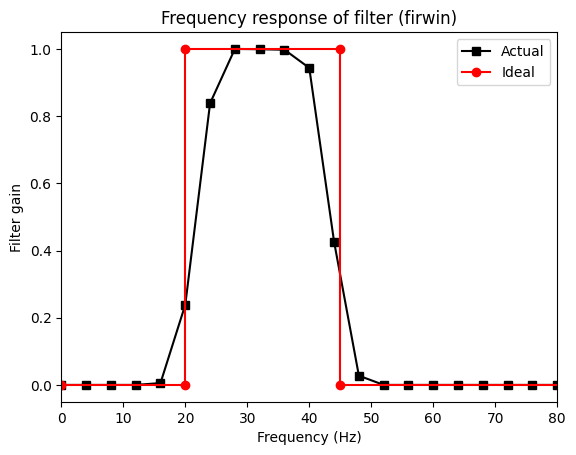

In [46]:
plt.plot(hz,filtpow,'ks-',label='Actual')
plt.plot([0,frange[0],frange[0],frange[1],frange[1],nyquist],[0,0,1,1,0,0],'ro-',label='Ideal')
plt.xlim([0,frange[0]*4])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Filter gain')
plt.legend()
plt.title('Frequency response of filter (firwin)')
plt.show()

Effect of filter order

In [48]:
orders = np.round(np.linspace( (srate/frange[0]) / (srate/1000),(15*srate/frange[0]) / (srate/1000), 10))

fkernx = np.zeros((len(orders),1000))
hz = np.linspace(0,srate,1000)
for oi in range(0,len(orders)):
    ord2use = orders[oi]+(1-orders[oi]%2)
    fkern = signal.firwin(int(ord2use), frange, fs=srate, pass_zero=False)
    fkernx[oi,:] = np.abs(fft(fkern,1000))**2

Plotting

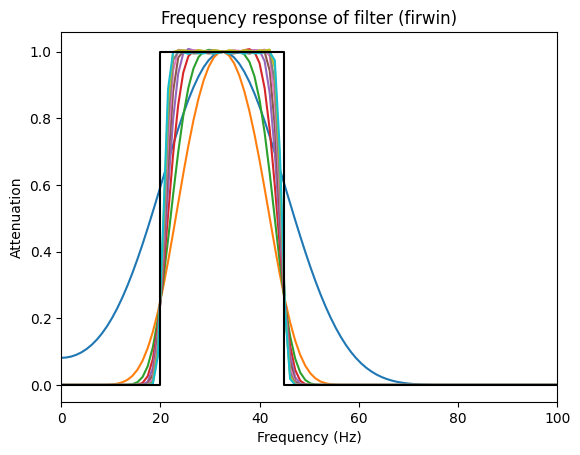

In [50]:
plt.plot(hz,fkernx.T)
plt.plot([0,frange[0],frange[0],frange[1],frange[1],nyquist],[0,0,1,1,0,0],'k')
plt.xlim([0,100])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Attenuation')
plt.title('Frequency response of filter (firwin)')
plt.show()